# Image Enhancement and FilteringGroups arithmetic and intensity adjustments with histogram methods, equalization, denoising, sharpening, and edge detection.

## Import libraries

In [1]:
# import Open CV library
import cv2

import matplotlib.pyplot as plt
import numpy as np

## Arithmetic operations
***cv2.add()***
- Performs pixel-wise addition of two images (or an image and a scalar).
- Iit uses saturation arithmetic. if the sum exceeds 255, the value is capped at 255 (no overflow).
- Example: <code>brighter = cv2.add(img, 50)   # adds 50 to all pixel values</code>

***cv2.subtract()***
- Performs pixel-wise subtraction.
- Also uses saturation arithmetic. if the result goes below 0, it is set to 0 (no underflow).
- Example: <code>darker = cv2.subtract(img, 50)   # subtracts 50 from all pixels</code>

***cv2.addWeighted()***
- Blends two images together using a weighted sum.
- Formula: $$\alpha.img1+\beta.img2+\gamma$$
- α and β : weights for each image (control transparency).
- γ : scalar added to the result (brightness adjustment).
- Example : <code>blended = cv2.addWeighted(img1, 0.7, img2, 0.3, 0)</code>

(np.float64(-0.5), np.float64(279.5), np.float64(349.5), np.float64(-0.5))

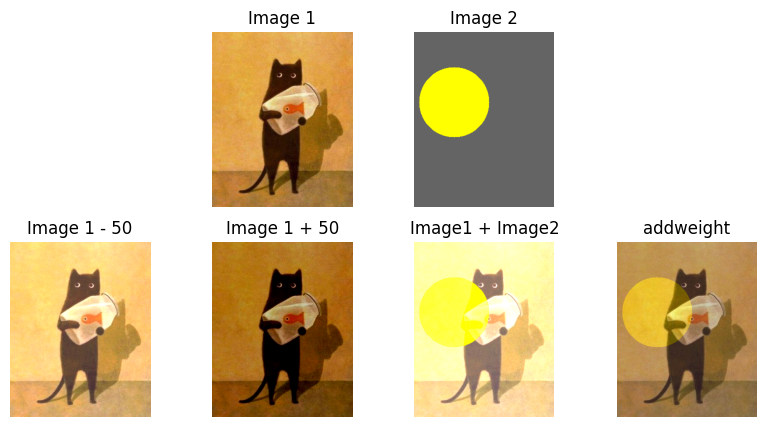

In [21]:
img1 = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)
img2 = np.ones(im.shape,dtype='uint8')*100
cv2.circle(img2,(80,140),70,(255,255,0),-1)

# add
brighter = cv2.add(img1, 50)
# add
added = cv2.add(img1,img2)
# subtract
darker = cv2.subtract(img1, 50)
# addweighted
blended = cv2.addWeighted(img1, 0.7, img2, 0.3, 0)

plt.figure(figsize=[10,5])
plt.subplot(242);plt.imshow(img1);plt.title("Image 1");plt.axis('off')
plt.subplot(243);plt.imshow(img2);plt.title("Image 2");plt.axis('off')
plt.subplot(245);plt.imshow(brighter);plt.title("Image 1 - 50");plt.axis('off')
plt.subplot(246);plt.imshow(darker);plt.title("Image 1 + 50");plt.axis('off')
plt.subplot(247);plt.imshow(added);plt.title("Image1 + Image2");plt.axis('off')
plt.subplot(248);plt.imshow(blended);plt.title("addweight");plt.axis('off')


## Brightness and Contrast (linear)
An image can be represented as a matrix where each element corresponds to the intensity value of a pixel (for grayscale) or a vector of values (for color channels). Adjusting brightness and contrast can be described using a linear transformation applied to each pixel.<br>
The general formula is: $$new Value=α⋅Value+β$$
- α : contrast factor (scale)
    - α>1: differences between light and dark regions are amplified → image looks sharper.
    - 0<α<1: differences are reduced → image looks flatter and duller
- β : brightness offset (shift)
    - This shifts all pixel values up or down equally.
    - The image becomes lighter or darker, but the difference between pixel values (contrast) remains the same.

OpenCV provides a built-in function that applies this transformation safely with saturation arithmetic:<br>
<code>cv2.convertScaleAbs(image, alpha, beta)</code>

(np.float64(-0.5), np.float64(279.5), np.float64(349.5), np.float64(-0.5))

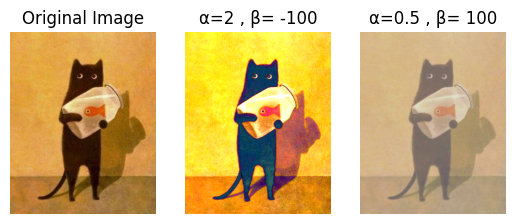

In [12]:
img = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)

im1 = cv2.convertScaleAbs(img,alpha= 2,beta= -100)
im2 = cv2.convertScaleAbs(img,alpha= 0.5,beta= 100)

plt.subplot(131);plt.imshow(img);plt.title("Original Image");plt.axis('off')
plt.subplot(132);plt.imshow(im1);plt.title("α=2 , β= -100");plt.axis('off')
plt.subplot(133);plt.imshow(im2);plt.title("α=0.5 , β= 100");plt.axis('off')



## Histogram
A histogram is a graphical representation of the distribution of pixel intensity values in an image. It shows how many pixels fall into each possible intensity level. It is a powerful tool for understanding image characteristics and for guiding image processing tasks like contrast adjustment, segmentation, and enhancement.<br>


The <code>plt.hist()</code> function is used to plot a histogram in Python with Matplotlib. It takes a sequence of data (such as pixel intensities from an image) and divides it into intervals called bins, then counts how many values fall into each bin. The result is displayed as a bar plot.

<code>plt.hist(data, bins=256, range=(0,256), color='gray')</code>
- <code>data</code> : input values (e.g., pixel intensities, often flattened using <code>.ravel()</code>).
- <code>bins</code> : number of intervals to divide the data into.
- <code>range</code> : the minimum and maximum values considered.
- <code>color</code> : bar color.


C:\Users\LCPart\AppData\Local\Temp\ipykernel_14448\3968672746.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(221);plt.hist(grey_im.ravel(),256,(0,256));plt.title("Greyscale Histogram")
C:\Users\LCPart\AppData\Local\Temp\ipykernel_14448\3968672746.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(223);plt.hist(im1.ravel(),256,(0,256));plt.title("α=2 , β= -100 Histogram")
C:\Users\LCPart\AppData\Local\Temp\ipykernel_14448\3968672746.py:9: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(224);plt.hist(im2.ravel(),256,(0,256));plt.title("α=0.5 , β= 100 Histogram")


Text(0.5, 1.0, 'α=0.5 , β= 100 Histogram')

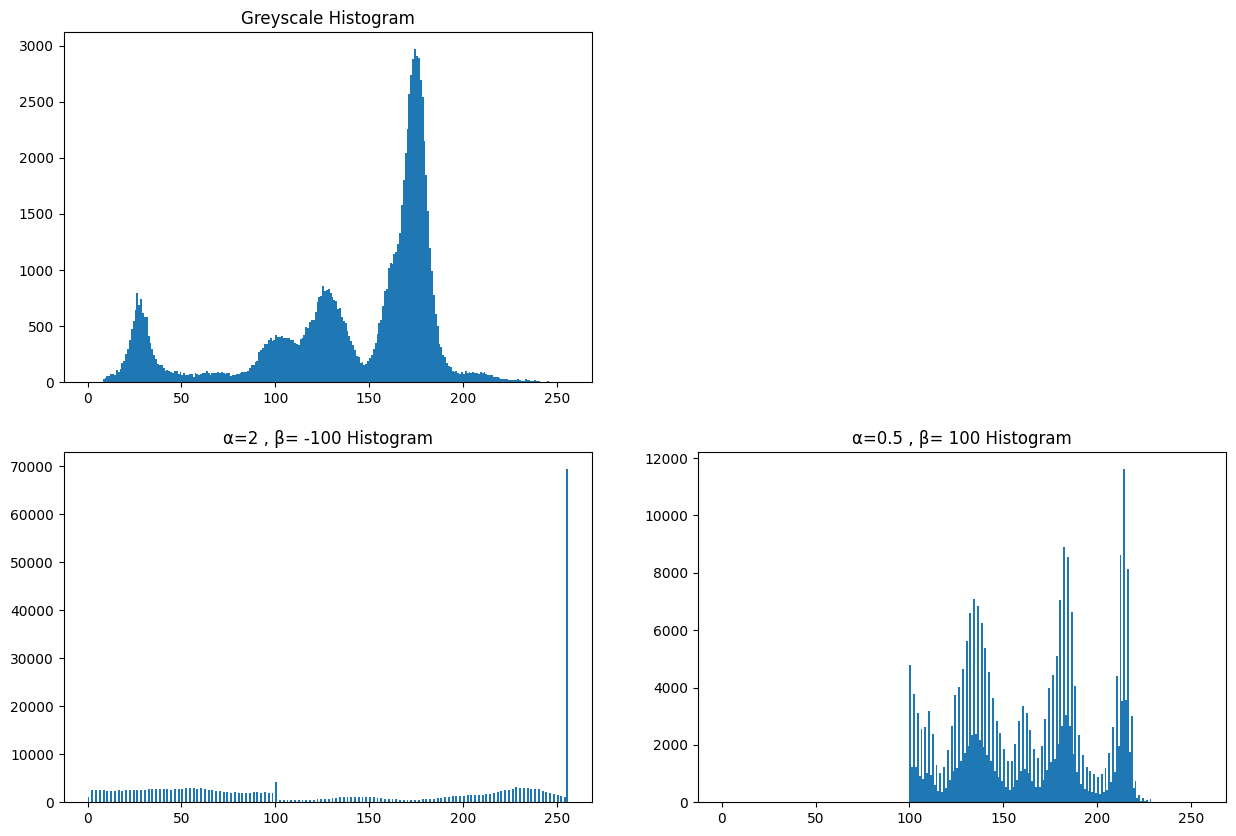

In [15]:
im = cv2.imread("images/Cat.jpg")

grey_im = cv2.cvtColor(im,cv2.COLOR_BGR2GRAY)
B,G,R = cv2.split(im)

plt.figure(figsize=[15,10])
plt.subplot(221);plt.hist(grey_im.ravel(),256,(0,256));plt.title("Greyscale Histogram")
plt.subplot(223);plt.hist(im1.ravel(),256,(0,256));plt.title("α=2 , β= -100 Histogram")
plt.subplot(224);plt.hist(im2.ravel(),256,(0,256));plt.title("α=0.5 , β= 100 Histogram")

In OpenCV, the function <code>cv2.calcHist()</code> is used to compute histograms efficiently for grayscale or color images.

<code>v2.calcHist(images, channels, mask, histSize, ranges)</code>
- <code>images</code>	List of images (usually <code>[img]</code>)
- <code>channels</code>	List of channels to compute (e.g., <code>[0]</code> for grayscale or <code>[0, 1, 2]</code> for color)
- <code>mask</code>	Optional mask image (to compute histogram of a specific region)
- <code>histSize</code>	Number of bins (e.g., <code>[256]</code> for 256 intensity levels)
- <code>ranges</code>	Intensity range (e.g., <code>[0, 256]</code>)

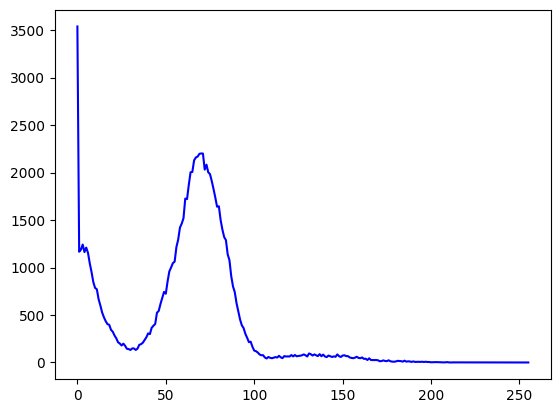

In [6]:
img = cv2.imread("images/Cat.jpg")

histogram = cv2.calcHist([img], [0] ,None ,[256] ,[0,256])

plt.plot(histogram ,color="blue")

## Gamma correction (non linear)
As observed in the histograms, when contrast is increased (α>1) using linear intensity scaling, a significant portion of image information can be lost due to saturation and clipping at the lower and upper intensity boundaries (0 and 255 for 8-bit images). This results in loss of detail in dark or bright regions.

To address this limitation, gamma correction is employed. Gamma correction applies a non-linear transformation to pixel intensities, expressed as:
$$NewValue = 255\times\left(\frac{Value}{255}\right)^{\gamma}$$
γ is the gamma value controlling the transformation.
- When γ<1: darker regions are brightened, improving visibility of shadow details.
- When γ>1: brighter regions are suppressed, enhancing details in highlights.

(np.float64(-0.5), np.float64(279.5), np.float64(349.5), np.float64(-0.5))

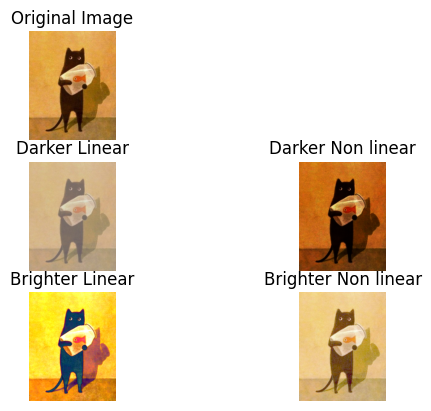

In [18]:
im = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)

def gamma_correction(image, gamma=1.0):
    # build a lookup table for efficiency
    table = np.array([( (i / 255.0) ** gamma ) * 255 for i in np.arange(256)]).astype("uint8")
    return cv2.LUT(image, table)

brighter_linear = cv2.convertScaleAbs(img,alpha= 2,beta= -100)
darker_linear = cv2.convertScaleAbs(img,alpha= 0.5,beta= 100)

brighter_non_linear = gamma_correction(im,gamma=0.5)
darker_non_linear = gamma_correction(im,gamma=2)

plt.subplot(321);plt.imshow(im);plt.title("Original Image");plt.axis('off')
plt.subplot(323);plt.imshow(darker_linear);plt.title("Darker Linear");plt.axis('off')
plt.subplot(324);plt.imshow(darker_non_linear);plt.title("Darker Non linear");plt.axis('off')
plt.subplot(325);plt.imshow(brighter_linear);plt.title("Brighter Linear");plt.axis('off')
plt.subplot(326);plt.imshow(brighter_non_linear);plt.title("Brighter Non linear");plt.axis('off')

## Histogram Equalization
Histogram equalization is a contrast enhancement technique used to improve the appearance of images, especially when lighting conditions are poor or uneven.

It works by redistributing pixel intensities so that they spread more evenly across the full intensity range (0–255).
This results in an image with higher global contrast, making dark areas lighter and bright areas more distinct.

Function:

 <code>cv2.equalizeHist(img)</code>

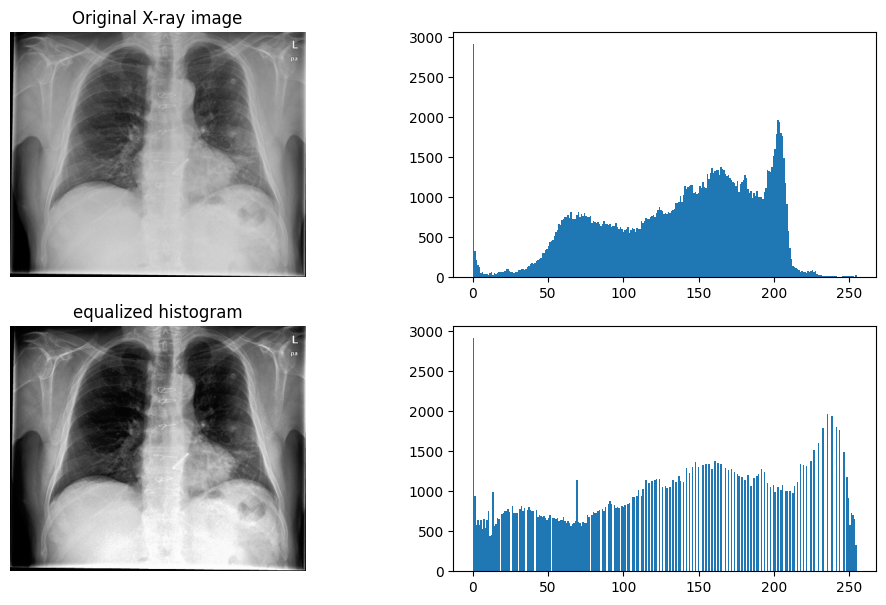

In [33]:
img = cv2.imread("images/xray.jpg",cv2.IMREAD_GRAYSCALE) 
equalized = cv2.equalizeHist(img)

plt.figure(figsize=[12,7])
plt.subplot(221);plt.imshow(img, cmap='gray');plt.title("Original X-ray image");plt.axis("off")
plt.subplot(222);plt.hist(img.ravel(), 256)
plt.subplot(223);plt.imshow(equalized, cmap='gray');plt.title("equalized histogram");plt.axis("off")
plt.subplot(224);plt.hist(equalized.ravel(), 256);

##### For Color Images:

You should not equalize all RGB channels independently it distorts colors.

Instead, convert the image to YCrCb or LAB and apply equalization only on the luminance channel (Y or L):

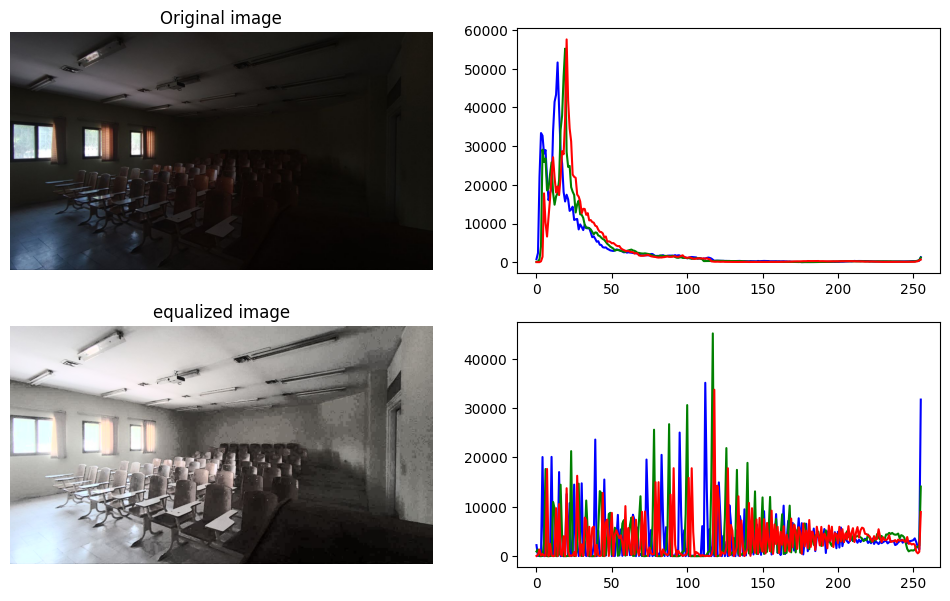

In [52]:
img = cv2.imread("images/classroom.jpg")
ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
y, cr, cb = cv2.split(ycrcb)

# Equalize only the luminance channel
y_eq = cv2.equalizeHist(y)

ycrcb_eq = cv2.merge((y_eq, cr, cb))
img_eq = cv2.cvtColor(ycrcb_eq, cv2.COLOR_YCrCb2BGR)


plt.figure(figsize=[12,7])
plt.subplot(221);plt.imshow(img[:,:,::-1]);plt.title("Original image");plt.axis("off")
color = ('b', 'g', 'r')
plt.subplot(222)
for i, col in enumerate(color):
    histogram = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(histogram, color = col)

plt.subplot(223);plt.imshow(img_eq[:,:,::-1]);plt.title("equalized image");plt.axis("off")
plt.subplot(224)
for i, col in enumerate(color):
    histogram = cv2.calcHist([img_eq], [i], None, [256], [0, 256])
    plt.plot(histogram, color = col)


## CLAHE Equalization
CLAHE (Contrast Limited Adaptive Histogram Equalization) is an improved version of standard histogram equalization that works locally instead of globally. While traditional histogram equalization enhances contrast using the entire image histogram, CLAHE enhances contrast in small regions (called tiles) of the image — then combines them smoothly.

CLAHE enhances local contrast and limits over-saturation or noise by clipping the histogram before redistribution.

Function:

<code>cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))</code>
- <code>clipLimit</code> : Threshold for contrast limiting. Larger values → higher contrast.
- <code>tileGridSize</code> : Size of the local regions (e.g., 8×8 tiles). Smaller tiles → stronger local enhancement.

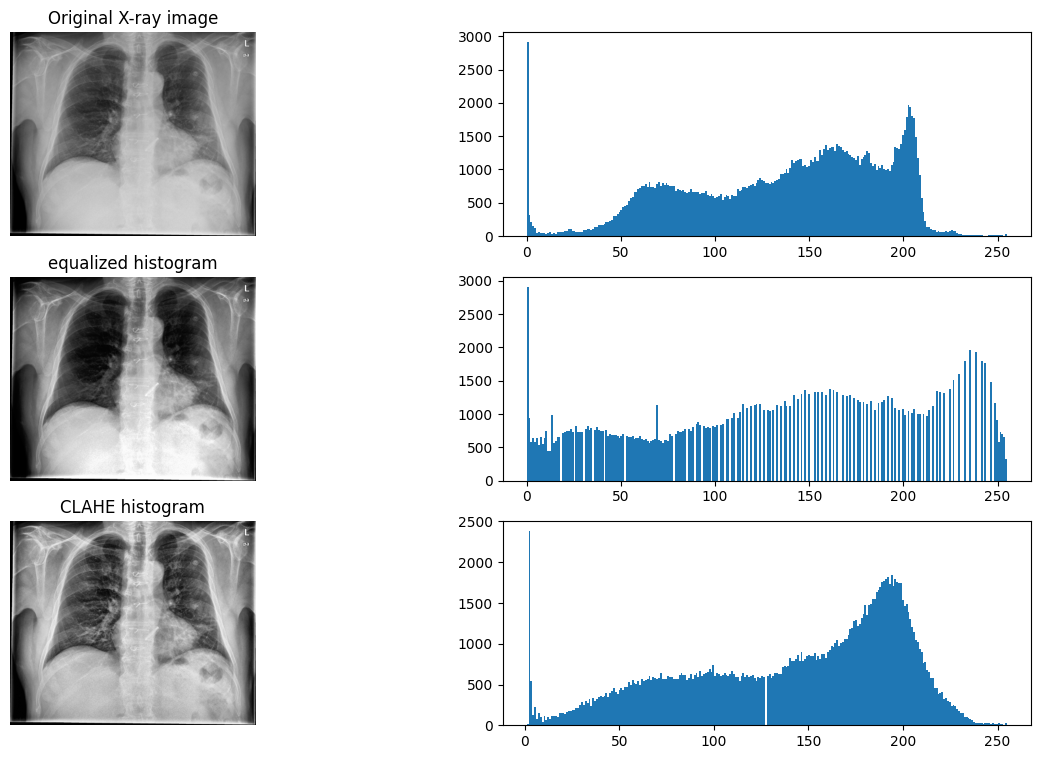

In [46]:
img = cv2.imread("images/xray.jpg",cv2.IMREAD_GRAYSCALE) 

equalized = cv2.equalizeHist(img)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(img)

plt.figure(figsize=[15,9])
plt.subplot(321);plt.imshow(img, cmap='gray');plt.title("Original X-ray image");plt.axis("off")
plt.subplot(322);plt.hist(img.ravel(), 256)
plt.subplot(323);plt.imshow(equalized, cmap='gray');plt.title("equalized histogram");plt.axis("off")
plt.subplot(324);plt.hist(equalized.ravel(), 256)
plt.subplot(325);plt.imshow(clahe_img, cmap='gray');plt.title("CLAHE histogram");plt.axis("off")
plt.subplot(326);plt.hist(clahe_img.ravel(), 256);


##### For Color Images:

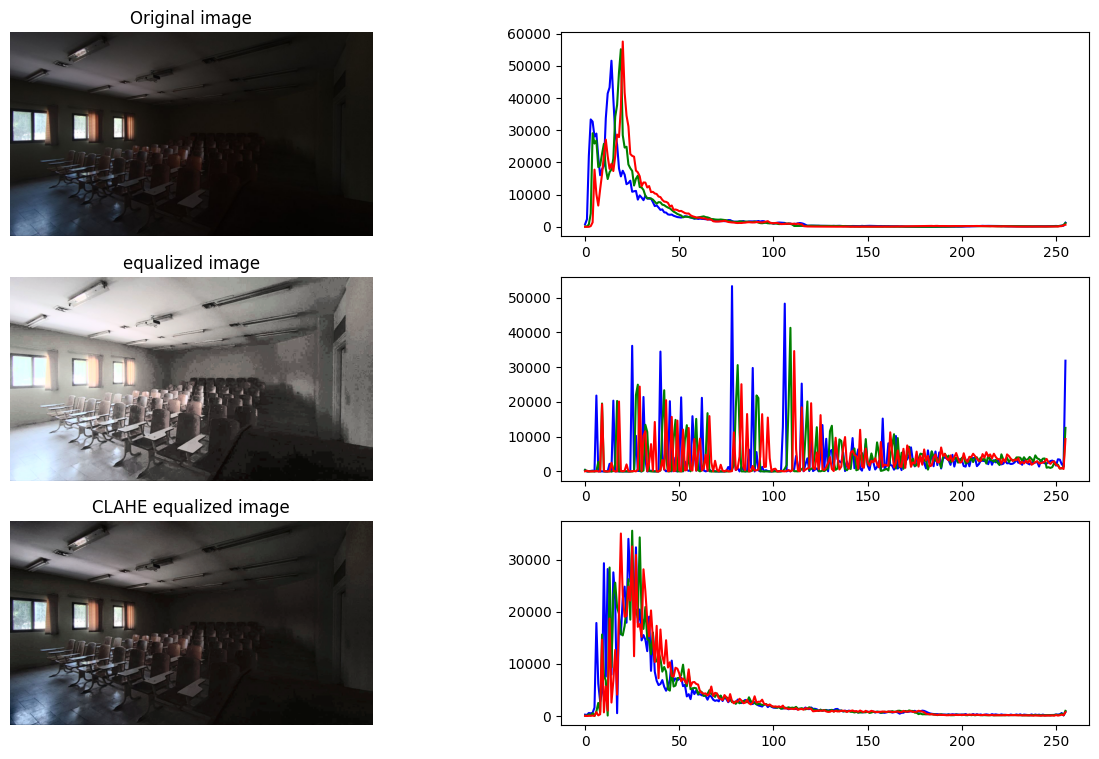

In [51]:
img = cv2.imread("images/classroom.jpg")
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

l_eq = cv2.equalizeHist(l)
lab_eq = cv2.merge((l_eq, a, b))
img_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)


clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l_eq = clahe.apply(l)
lab_eq = cv2.merge((l_eq, a, b))
clahe_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

color = ('b', 'g', 'r')
plt.figure(figsize=[15,9])

plt.subplot(321);plt.imshow(img[:,:,::-1]);plt.title("Original image");plt.axis("off")
plt.subplot(322)
for i, col in enumerate(color):
    histogram = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(histogram, color = col)

plt.subplot(323);plt.imshow(img_eq[:,:,::-1]);plt.title("equalized image");plt.axis("off")
plt.subplot(324)
for i, col in enumerate(color):
    histogram = cv2.calcHist([img_eq], [i], None, [256], [0, 256])
    plt.plot(histogram, color = col)

plt.subplot(325);plt.imshow(clahe_eq[:,:,::-1]);plt.title("CLAHE equalized image");plt.axis("off")
plt.subplot(326)
for i, col in enumerate(color):
    histogram = cv2.calcHist([clahe_eq], [i], None, [256], [0, 256])
    plt.plot(histogram, color = col)

## Blurring and Denoising
OpenCV provides several functions to reduce noise or smooth the image using different types of filters.

### 1.Mean Filter :
Each pixel is replaced by the average value of its neighboring pixels, using a rectangular kernel.

<code>blur = cv2.blur(img, (5,5))</code>

### 2.Gaussian Blur :
Weights neighboring pixels using a Gaussian (bell-shaped) kernel, giving more importance to central pixels.

<code>gaussian = cv2.GaussianBlur(img, (5,5), 0)</code>

### 3.Median Blur :
Each pixel value is replaced with the median of its neighborhood.

<code>median = cv2.medianBlur(img, 5)</code>

### 4.Bilateral Filter :
A more advanced, edge-preserving smoothing filter. It combines spatial proximity (like Gaussian blur) & pixel intensity similarity


<code>bilateral = cv2.bilateralFilter(img, 9, 75, 75)</code>
| Parameter | Meaning                              |
| --------- | ------------------------------------ |
| `9`       | Diameter of pixel neighborhood       |
| `75`      | σColor — intensity difference weight |
| `75`      | σSpace — spatial distance weight     |


### 5. Non-Local Means Denoising (Advanced) :
OpenCV provides a non-local means algorithm that averages similar patches across the image — not just nearby pixels.

for GrayScale:<br>
<code>denoised = cv2.fastNlMeansDenoising(img, None, h=10, templateWindowSize=7, searchWindowSize=21)</code>

for Color:<br>
<code>denoised_color = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)</code>

| Parameter            | Description                                  |
| -------------------- | -------------------------------------------- |
| `h`                  | Filtering strength (larger = more smoothing) |
| `templateWindowSize` | Size of pixel patch compared                 |
| `searchWindowSize`   | Area used to find similar patches            |



Text(0.5, 1.0, 'Non-Local Means Denoising')

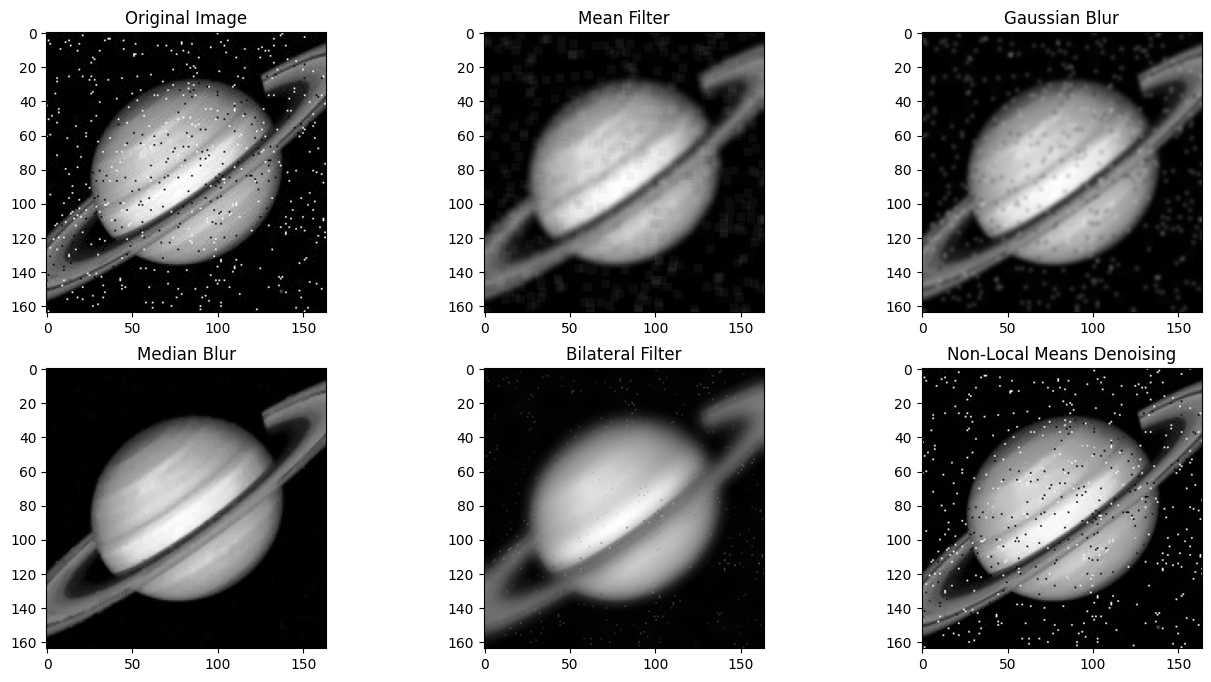

In [5]:
img = cv2.imread("images/noisy-saturn.jpg",0)

blur = cv2.blur(img, (5,5))
gauss = cv2.GaussianBlur(img , (5,5),0)
median = cv2.medianBlur(img ,3)
bilateral = cv2.bilateralFilter(img, 15, 129, 120)
denoised = cv2.fastNlMeansDenoising(img, None, h=10, templateWindowSize=7, searchWindowSize=21)

plt.figure(figsize=[16,8])
plt.subplot(231);plt.imshow(img,cmap='gray');plt.title("Original Image")
plt.subplot(232);plt.imshow(blur,cmap='gray');plt.title("Mean Filter")
plt.subplot(233);plt.imshow(gauss,cmap='gray');plt.title("Gaussian Blur")
plt.subplot(234);plt.imshow(median,cmap='gray');plt.title("Median Blur")
plt.subplot(235);plt.imshow(bilateral,cmap='gray');plt.title("Bilateral Filter")
plt.subplot(236);plt.imshow(denoised,cmap='gray');plt.title("Non-Local Means Denoising")

Text(0.5, 1.0, 'Non-Local Means Denoising')

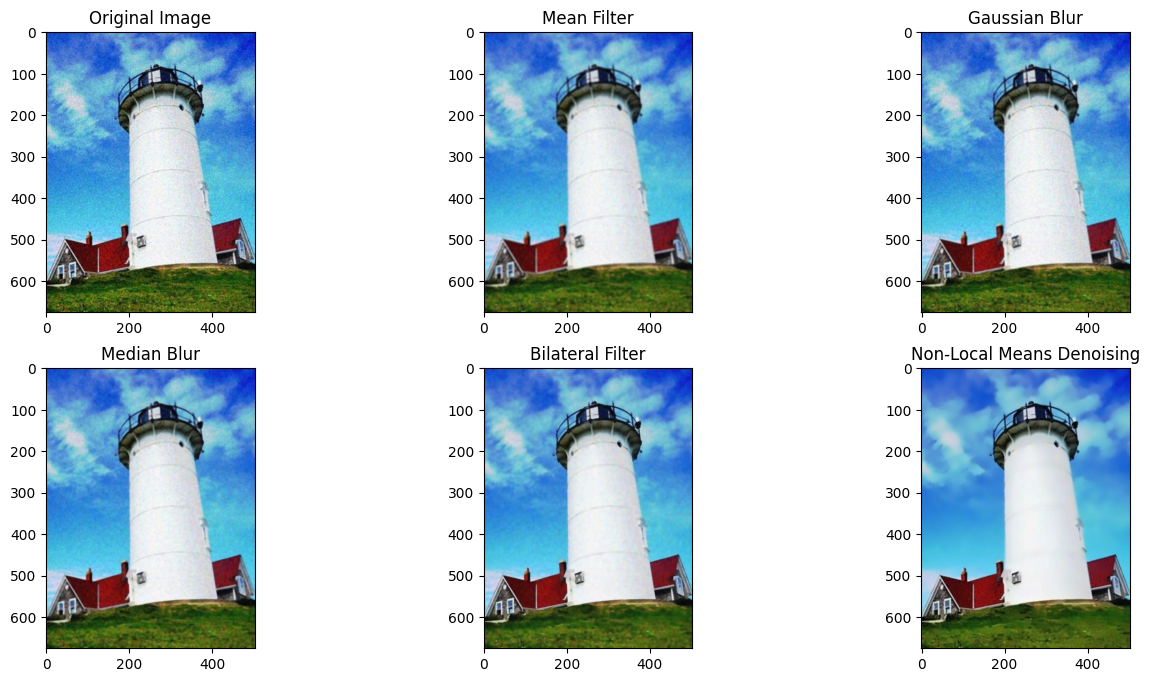

In [15]:
img = cv2.imread("images/noisy-colorimg.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

blur = cv2.blur(img, (5,5))
gauss = cv2.GaussianBlur(img , (5,5),0)
median = cv2.medianBlur(img ,5)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)
denoised = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

plt.figure(figsize=[16,8])
plt.subplot(231);plt.imshow(img,cmap='gray');plt.title("Original Image")
plt.subplot(232);plt.imshow(blur,cmap='gray');plt.title("Mean Filter")
plt.subplot(233);plt.imshow(gauss,cmap='gray');plt.title("Gaussian Blur")
plt.subplot(234);plt.imshow(median,cmap='gray');plt.title("Median Blur")
plt.subplot(235);plt.imshow(bilateral,cmap='gray');plt.title("Bilateral Filter")
plt.subplot(236);plt.imshow(denoised,cmap='gray');plt.title("Non-Local Means Denoising")

## Sharpening
Image sharpening is the process of enhancing the edges and fine details of an image. Sharpening is usually achieved by subtracting a blurred version of the image from the original image.
$$Sharpened Image=Original+α(Original−Blurred)$$
α controls how strong the sharpening effect is.

Sharpening Using a Kernel :
$$\begin{bmatrix}0 & -1 & 0 \\-1 & 5 & -1 \\0 & -1 & 0\end{bmatrix}$$

Text(0.5, 1.0, 'Sharpened Image')

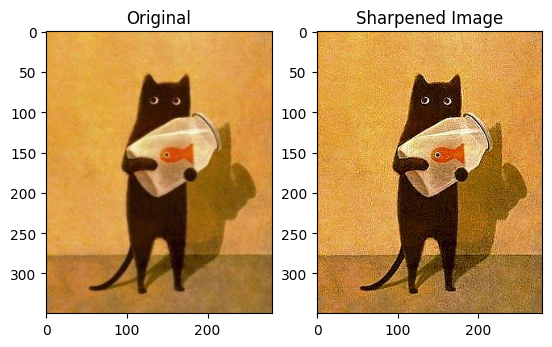

In [ ]:
img = cv2.imread("images/Cat.jpg",cv2.IMREAD_COLOR_RGB)

kernel = np.array([[0,-1, 0],
                   [-1,5,-1],
                   [0,-1, 0]])

sharpened = cv2.filter2D(img,-1,kernel)

plt.subplot(121); plt.imshow(img); plt.title("Original")
plt.subplot(122); plt.imshow(sharpened); plt.title("Sharpened Image")

## Edge Detection
Edge detection is the process of finding sharp changes (discontinuities) in image intensity. Edges correspond to high gradients in the image. A gradient measures the rate of intensity change between neighboring pixels.

### 1. Sobel Operator
Sobel detects edges by computing the gradients in the x and/or y direction.

Function:
<code>cv2.Sobel(img, ddepth, dx, dy, ksize)</code>

- <code>ddepth</code> : Desired depth of the output image (e.g., <code>cv2.CV_64F</code> for accurate gradients).
- <code>dx & dy</code> : Order of derivative in the x and y direction (1,0 : x  ,  0,1 : y)
- <code>ksize</code> : Kernel size (most be odd)

Text(0.5, 1.0, 'Sobel Magnitude (Combined)')

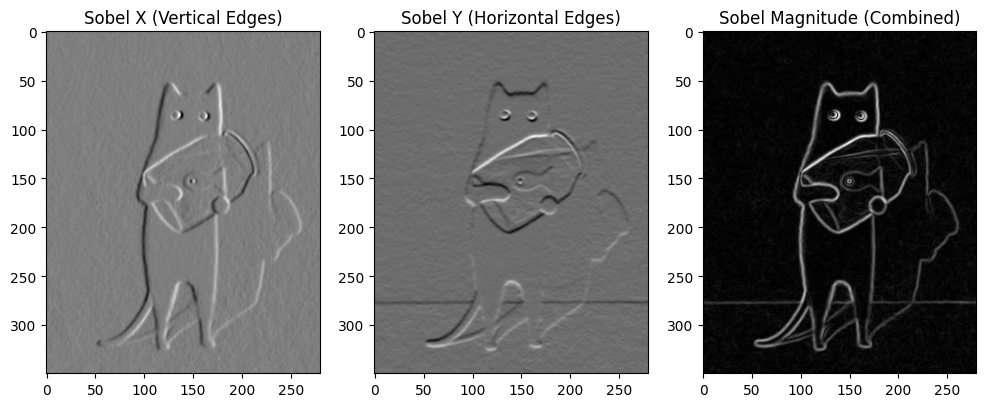

In [42]:
img = cv2.imread("images/Cat.jpg",0)
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

# Compute magnitude of gradients (combines the two)
sobel = cv2.magnitude(sobelx, sobely)

plt.figure(figsize=(12,5))
plt.subplot(131); plt.imshow(sobelx, cmap='gray'); plt.title("Sobel X (Vertical Edges)")
plt.subplot(132); plt.imshow(sobely, cmap='gray'); plt.title("Sobel Y (Horizontal Edges)")
plt.subplot(133); plt.imshow(sobel, cmap='gray'); plt.title("Sobel Magnitude (Combined)")

### 2. Laplacian Operator
The Laplacian operator calculates the second derivative of the image intensity. It detects regions where the intensity changes rapidly in all directions. It is isotropic, meaning it does not depend on edge orientation.

Function:
<code>cv2.Laplacian(img, cv2.CV_64F)</code>

Text(0.5, 1.0, 'Laplacian Edge Detection')

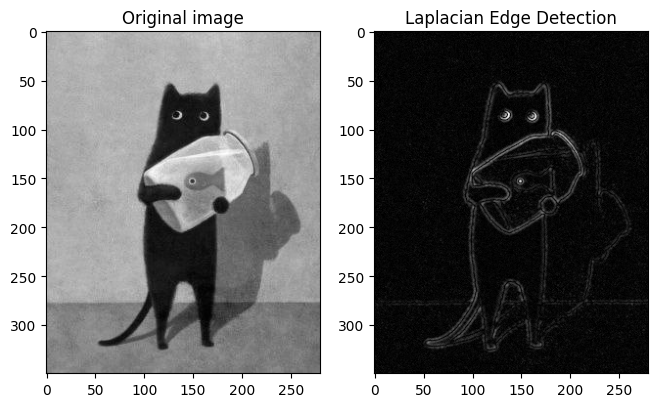

In [46]:
img = cv2.imread("images/Cat.jpg",0)
blurimg = cv2.GaussianBlur(img, (5,5) ,0)
laplacian = cv2.Laplacian(blurimg,cv2.CV_64F)

# convert to abs and scale to 0-255
laplacian = cv2.convertScaleAbs(laplacian)

plt.figure(figsize=(12,5))
plt.subplot(131); plt.imshow(img, cmap='gray'); plt.title("Original image")
plt.subplot(132); plt.imshow(laplacian, cmap='gray'); plt.title("Laplacian Edge Detection")

### 3. Canny Edge Detector
Canny is a multi-stage algorithm designed to detect edges accurately while minimizing noise and false detections.

It is considered the gold standard of edge detection because it:

- Produces thin, well-connected edges

- Suppresses noise effectively

- Reduces false positives (non-edge pixels detected as edges)

Function:
<code>cv2.Canny(img, threshold1, threshold2, ksize, L2gradient=False)</code>


- <code>image</code> : grayscale required.                  
- <code>threshold1</code> : Lower threshold for hysteresis.                                          
- <code>threshold2</code> : Upper threshold for hysteresis.                   
- <code>ksize</code> Kernel size for Sobel operator (default = 3).    
- <code>L2gradient</code> : 
    - <code>False</code> : faster, uses absolute gradient sum (default).
    - <code>True</code> : more accurate, uses Euclidean norm for gradient magnitude.



Text(0.5, 1.0, 'Canny (L2gradient=True)')

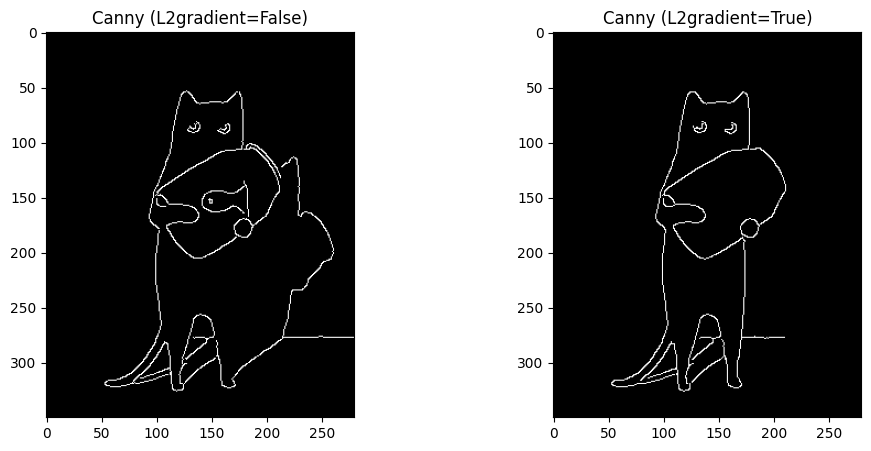

In [49]:
img = cv2.imread("images/Cat.jpg", cv2.IMREAD_GRAYSCALE)
blur = cv2.GaussianBlur(img, (5,5), 1.4)

# Apply Canny with both options
edges_L1 = cv2.Canny(blur, 50, 200, L2gradient=False)
edges_L2 = cv2.Canny(blur, 50, 200, L2gradient=True)

# Display results
plt.figure(figsize=(12,5))
plt.subplot(121); plt.imshow(edges_L1, cmap='gray'); plt.title("Canny (L2gradient=False)")
plt.subplot(122); plt.imshow(edges_L2, cmap='gray'); plt.title("Canny (L2gradient=True)")